# AI-DRIVEN RISK-AWARE PORTFOLIO ALLOCATION SYSTEM

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import cvxpy as cp

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
from xgboost import XGBRegressor


# 1. DOWNLOAD DATA

In [2]:
tickers = ["AAPL", "MSFT", "NVDA", "JPM", "AMZN"]

prices = yf.download(tickers, start="2015-01-01", end="2024-01-01")["Close"]

returns = np.log(prices / prices.shift(1)).dropna()

/tmp/ipython-input-1650518903.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start="2015-01-01", end="2024-01-01")["Close"]
[*********************100%***********************]  5 of 5 completed


# 2. FEATURE ENGINEERING

In [3]:
features = {}

for t in tickers:
    df = pd.DataFrame(index=returns.index)

    df["mom_5"] = returns[t].rolling(5).sum()
    df["mom_20"] = returns[t].rolling(20).sum()
    df["vol_20"] = returns[t].rolling(20).std()
    df["vol_60"] = returns[t].rolling(60).std()

    features[t] = df

features = pd.concat(features, axis=1).dropna()

# 3. PORTFOLIO OPTIMIZER

In [4]:
def optimize_portfolio(mu, cov, risk_aversion, prev_w):

    n = len(mu)
    w = cp.Variable(n)

    objective = cp.Maximize(
        mu @ w
        - risk_aversion * cp.quad_form(w, cov)
        - 0.1 * cp.norm1(w - prev_w)
    )

    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= 0.5
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve()

    return w.value


# 4. BACKTEST SETTINGS

In [5]:
window = 252
risk_aversion = 10
transaction_cost_rate = 0.001

portfolio_returns = []
equal_weight_returns = []
weights_history = []
feature_importances = []

prev_weights = np.zeros(len(tickers))

# 5. ROLLING BACKTEST

In [6]:
portfolio_returns_ridge = []
portfolio_returns_xgb = []
equal_weight_returns = []

weights_history_ridge = []
weights_history_xgb = []

prev_weights_ridge = np.zeros(len(tickers))
prev_weights_xgb = np.zeros(len(tickers))

feature_importances = []   # final storage (one vector per time step)

for t in range(window, len(features) - 21, 21):

    mu_ridge = []
    mu_xgb = []
    step_importance = []   # store coefficients for this time step

    for asset in tickers:

        X = features[asset]
        y = returns[asset].rolling(21).sum().shift(-21)
        y = y.loc[X.index]

        X_train = X.iloc[t-window:t]
        y_train = y.iloc[t-window:t]
        X_test = X.iloc[t:t+1]

        if len(X_train) == 0 or len(X_test) == 0:
            continue

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # -------- RIDGE --------
        ridge = Ridge(alpha=1.0)
        ridge.fit(X_train_scaled, y_train)

        mu_ridge.append(ridge.predict(X_test_scaled)[0])
        step_importance.append(np.abs(ridge.coef_))  # store abs coefficients

        # -------- XGBOOST --------
        xgb = XGBRegressor(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        xgb.fit(X_train, y_train)
        mu_xgb.append(xgb.predict(X_test)[0])

    if len(mu_ridge) != len(tickers):
        continue

    mu_ridge = np.array(mu_ridge)
    mu_xgb = np.array(mu_xgb)

    # ----- Average feature importance across assets for this step -----
    step_importance = np.array(step_importance)
    feature_importances.append(step_importance.mean(axis=0))

    # ----- Covariance -----
    lw = LedoitWolf()
    cov = lw.fit(returns.iloc[t-window:t]).covariance_

    # ----- Optimize -----
    weights_ridge = optimize_portfolio(mu_ridge, cov, risk_aversion, prev_weights_ridge)
    weights_xgb = optimize_portfolio(mu_xgb, cov, risk_aversion, prev_weights_xgb)

    # ----- Transaction costs -----
    cost_ridge = 0.001 * np.sum(np.abs(weights_ridge - prev_weights_ridge))
    cost_xgb = 0.001 * np.sum(np.abs(weights_xgb - prev_weights_xgb))

    realized = returns.iloc[t:t+21].sum()

    r_ridge = realized.values @ weights_ridge - cost_ridge
    r_xgb = realized.values @ weights_xgb - cost_xgb
    r_equal = realized.mean()

    portfolio_returns_ridge.append(r_ridge)
    portfolio_returns_xgb.append(r_xgb)
    equal_weight_returns.append(r_equal)

    weights_history_ridge.append(weights_ridge)
    weights_history_xgb.append(weights_xgb)

    prev_weights_ridge = weights_ridge
    prev_weights_xgb = weights_xgb


In [7]:
def run_backtest_for_lambda(risk_aversion):

    portfolio_returns = []
    prev_weights = np.zeros(len(tickers))

    for t in range(window, len(features) - 21, 21):

        mu = []

        for asset in tickers:

            X = features[asset]
            y = returns[asset].rolling(21).sum().shift(-21)
            y = y.loc[X.index]

            X_train = X.iloc[t-window:t]
            y_train = y.iloc[t-window:t]
            X_test = X.iloc[t:t+1]

            if len(X_train) == 0:
                continue

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            model = Ridge(alpha=1.0)
            model.fit(X_train_scaled, y_train)
            mu.append(model.predict(X_test_scaled)[0])

        if len(mu) != len(tickers):
            continue

        mu = np.array(mu)

        from sklearn.covariance import LedoitWolf
        lw = LedoitWolf()
        cov = lw.fit(returns.iloc[t-window:t]).covariance_

        weights = optimize_portfolio(mu, cov, risk_aversion, prev_weights)

        cost = 0.001 * np.sum(np.abs(weights - prev_weights))
        realized = returns.iloc[t:t+21].sum()

        r = realized.values @ weights - cost
        portfolio_returns.append(r)

        prev_weights = weights

    r_series = pd.Series(portfolio_returns)

    annual_return = r_series.mean() * 12
    annual_vol = r_series.std() * np.sqrt(12)
    sharpe = annual_return / annual_vol

    return sharpe

In [8]:
lambdas = np.linspace(1, 20, 15)
sharpes = []

for lam in lambdas:
    sharpe = run_backtest_for_lambda(lam)
    sharpes.append(sharpe)

# 6. CONVERT TO SERIES

In [9]:
dates = returns.index[window:len(portfolio_returns_ridge)*21 + window:21]

ridge_series = pd.Series(portfolio_returns_ridge, index=dates)
xgb_series = pd.Series(portfolio_returns_xgb, index=dates)
equal_series = pd.Series(equal_weight_returns, index=dates)

# 7. PERFORMANCE METRICS

In [10]:
def performance_metrics(r):

    annual_return = r.mean() * 12
    annual_vol = r.std() * np.sqrt(12)
    sharpe = annual_return / annual_vol

    cumulative = (1 + r).cumprod()
    drawdown = cumulative / cumulative.cummax() - 1
    max_dd = drawdown.min()

    return annual_return, annual_vol, sharpe, max_dd


In [11]:
print("\n===== RIDGE Portfolio =====")
print(performance_metrics(ridge_series))

print("\n===== XGBOOST Portfolio =====")
print(performance_metrics(xgb_series))

print("\n===== Equal Weight =====")
print(performance_metrics(equal_series))



===== RIDGE Portfolio =====
(np.float64(0.26904007490086135), np.float64(0.25546222120075623), np.float64(1.0531501434391541), -0.37345736418758424)

===== XGBOOST Portfolio =====
(np.float64(0.295045894716785), np.float64(0.2775436437447032), np.float64(1.063061256730423), -0.4240940610664231)

===== Equal Weight =====
(np.float64(0.27322079095006935), np.float64(0.24732085101988707), np.float64(1.1047220233287152), -0.4158924788358398)


# 8. PLOTS

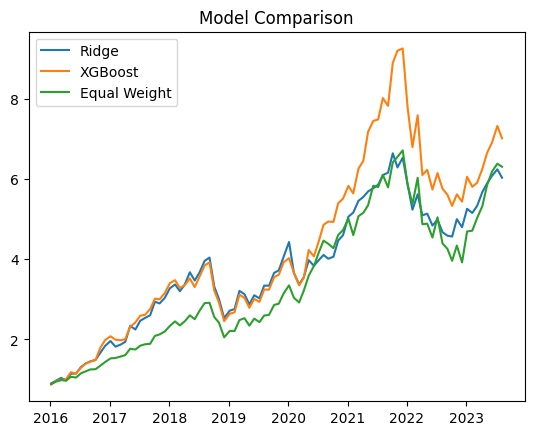

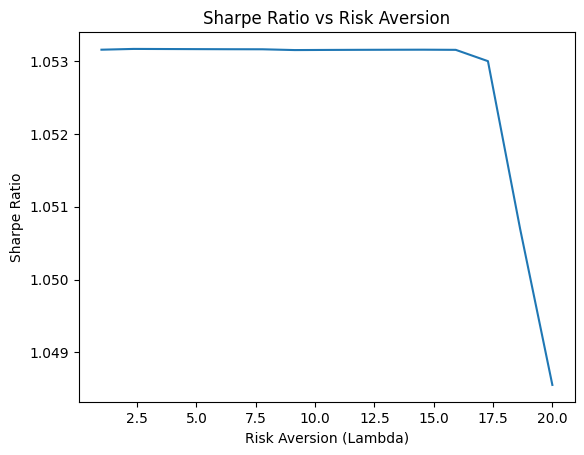

In [12]:
plt.figure()
plt.plot((1 + ridge_series).cumprod(), label="Ridge")
plt.plot((1 + xgb_series).cumprod(), label="XGBoost")
plt.plot((1 + equal_series).cumprod(), label="Equal Weight")
plt.legend()
plt.title("Model Comparison")
plt.show()

plt.figure()
plt.plot(lambdas, sharpes)
plt.xlabel("Risk Aversion (Lambda)")
plt.ylabel("Sharpe Ratio")
plt.title("Sharpe Ratio vs Risk Aversion")
plt.show()


# 9. FEATURE IMPORTANCE

In [13]:
feature_importances = np.array(feature_importances)

avg_importance = feature_importances.mean(axis=0)

feature_names = features[tickers[0]].columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": avg_importance
}).sort_values("Importance", ascending=False)

print("\n===== Average Rolling Feature Importance (Ridge) =====")
print(importance_df)



===== Average Rolling Feature Importance (Ridge) =====
  Feature  Importance
3  vol_60    0.028411
2  vol_20    0.021856
1  mom_20    0.019916
0   mom_5    0.007213
